In [1]:
# ── Prerequisites: imports + reload generated data from disk ──────────────────
# Lets the power-law fit / statsmodels cells below run WITHOUT re-running the
# (expensive) Pythia generation cells. Rebuilds `valid` and `multi_valid` from
# the saved CSVs (generations.csv, generations_multi.csv).
import re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# zero-shot single-number run  ->  `valid`
_g = pd.read_csv("generations.csv")
_num = pd.to_numeric(_g["number"], errors="coerce")
valid = [int(v) for v in _num.dropna() if 1 <= int(v) <= 100]

# "list of numbers" run  ->  `multi_valid`
_gm = pd.read_csv("generations_multi.csv")
multi_valid = [int(x)
               for s in _gm["numbers"].dropna()
               for x in str(s).split("|") if x.strip()]
multi_valid = [v for v in multi_valid if 1 <= v <= 100]

print(f"loaded valid       : {len(valid):,} numbers  (from generations.csv)")
print(f"loaded multi_valid : {len(multi_valid):,} numbers  (from generations_multi.csv)")


loaded valid       : 65,825 numbers  (from generations.csv)
loaded multi_valid : 48,108 numbers  (from generations_multi.csv)


In [2]:
%%capture
%pip install torch transformers
%pip install -U "huggingface_hub[cli]"
%pip install accelerate

# (recommended inside a fresh venv/conda env)
%pip uninstall -y huggingface_hub
%pip install "huggingface-hub>=0.34.0,<1.0"
# sanity check
%python -c "import transformers, huggingface_hub as h; print('transformers', transformers.__version__, 'hub', h.__version__)"

In [3]:
import os
os.environ["HF_HOME"] = "./hf"
os.environ["HF_HUB_CACHE"] = "./hf/hub"
os.environ['PATH'] += ':/storage/home/hcoda1/9/kzhang430/.local/bin'
os.environ.setdefault("HF_HOME", "./hf")
os.environ.setdefault("HF_HUB_CACHE", "./hf/hub")
os.environ.setdefault("HF_DATASETS_CACHE", "./hf/datasets")
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
import re
import json
from huggingface_hub import login

In [3]:
!hf auth whoami

user:  wristycargo


In [4]:
MODEL_NAME = "EleutherAI/pythia-12b-deduped"

In [5]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_REVISION = "step143000"   # final Pythia checkpoint; pin for reproducibility

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, revision=MODEL_REVISION)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, revision=MODEL_REVISION, torch_dtype=dtype).to(device)
model.eval()

# decoder-only model: pad on the left for batched generation
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"
print("loaded", MODEL_NAME, "@", MODEL_REVISION, "on", device, dtype)

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

loaded EleutherAI/pythia-12b-deduped @ step143000 on cuda torch.float16


In [6]:
# environment capture for the methods section
import sys, platform, json
import matplotlib
import transformers, accelerate, huggingface_hub

def collect_env():
    env = {
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "torch": torch.__version__,
        "torch_cuda_build": torch.version.cuda,
        "cudnn": torch.backends.cudnn.version(),
        "transformers": transformers.__version__,
        "accelerate": accelerate.__version__,
        "huggingface_hub": huggingface_hub.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "matplotlib": matplotlib.__version__,
        "model": MODEL_NAME,
        "revision": MODEL_REVISION,
        "dtype": str(dtype),
    }
    if torch.cuda.is_available():
        props = torch.cuda.get_device_properties(0)
        env["gpu"] = torch.cuda.get_device_name(0)
        env["gpu_mem_GB"] = round(props.total_memory / 1e9, 1)
        env["gpu_count"] = torch.cuda.device_count()
    return env

env = collect_env()
print(json.dumps(env, indent=2))
with open("environment.json", "w") as f:
    json.dump(env, f, indent=2)
print("\nsaved environment.json")

{
  "python": "3.9.12",
  "platform": "Linux-5.14.0-570.100.1.el9_6.x86_64-x86_64-with-glibc2.34",
  "torch": "2.7.0+cu126",
  "torch_cuda_build": "12.6",
  "cudnn": 90501,
  "transformers": "4.52.4",
  "accelerate": "1.10.1",
  "huggingface_hub": "0.36.2",
  "numpy": "1.21.5",
  "pandas": "1.4.2",
  "matplotlib": "3.5.1",
  "model": "EleutherAI/pythia-12b-deduped",
  "revision": "step143000",
  "dtype": "torch.float16",
  "gpu": "NVIDIA H200",
  "gpu_mem_GB": 150.1,
  "gpu_count": 1
}

saved environment.json


In [13]:
N_SAMPLES = 100000
BATCH_SIZE = 100
TEMPERATURE = 1.0
PROMPT = "Question: Generate a random number between 1 and 100.\nAnswer:"

torch.manual_seed(0)
inputs = tokenizer([PROMPT] * BATCH_SIZE, return_tensors="pt").to(device)

generations = []
for start in range(0, N_SAMPLES, BATCH_SIZE):
    n = min(BATCH_SIZE, N_SAMPLES - start)
    batch = {k: v[:n] for k, v in inputs.items()}
    with torch.no_grad():
        out = model.generate(
            **batch,
            do_sample=True,
            temperature=TEMPERATURE,
            top_k=0,          # no top-k truncation
            top_p=1.0,        # no nucleus truncation
            max_new_tokens=6,
            pad_token_id=tokenizer.pad_token_id,
        )
    # keep only the newly generated tokens
    new_tokens = out[:, batch["input_ids"].shape[1]:]
    generations.extend(tokenizer.batch_decode(new_tokens, skip_special_tokens=True))
    print(f"generated {start + n}/{N_SAMPLES}")

print("\nsample raw outputs:")
for g in generations[:10]:
    print(repr(g))

generated 100/100000
generated 200/100000
generated 300/100000
generated 400/100000
generated 500/100000
generated 600/100000
generated 700/100000
generated 800/100000
generated 900/100000
generated 1000/100000
generated 1100/100000
generated 1200/100000
generated 1300/100000
generated 1400/100000
generated 1500/100000
generated 1600/100000
generated 1700/100000
generated 1800/100000
generated 1900/100000
generated 2000/100000
generated 2100/100000
generated 2200/100000
generated 2300/100000
generated 2400/100000
generated 2500/100000
generated 2600/100000
generated 2700/100000
generated 2800/100000
generated 2900/100000
generated 3000/100000
generated 3100/100000
generated 3200/100000
generated 3300/100000
generated 3400/100000
generated 3500/100000
generated 3600/100000
generated 3700/100000
generated 3800/100000
generated 3900/100000
generated 4000/100000
generated 4100/100000
generated 4200/100000
generated 4300/100000
generated 4400/100000
generated 4500/100000
generated 4600/1000

In [14]:
def parse_number(text):
    """First integer in 1..100 appearing in the generated text, else None."""
    for m in re.findall(r"\d+", text):
        v = int(m)
        if 1 <= v <= 100:
            return v
    return None

numbers = [parse_number(g) for g in generations]
valid = [v for v in numbers if v is not None]
print(f"parsed {len(valid)}/{len(numbers)} valid numbers in [1, 100]")

counts = pd.Series(valid).value_counts().sort_index()
print("most common:", counts.sort_values(ascending=False).head(10).to_dict())

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(np.arange(1, 101),
       [counts.get(i, 0) for i in range(1, 101)],
       width=0.9, color="steelblue")
ax.set_xlabel("number")
ax.set_ylabel("frequency")
ax.set_title(f"{MODEL_NAME}: 'random' number 1-100 (T={TEMPERATURE}, n={len(valid)})")
ax.set_xlim(0, 101)
plt.tight_layout()
plt.savefig("number_distribution.png", dpi=120)
plt.show()

NameError: name 'generations' is not defined

parsed 65826/100000 valid numbers in [1, 100]
most common: {1: 8840, 100: 3129, 50: 2262, 5: 1821, 10: 1796, 2: 1699, 3: 1620, 25: 1540, 42: 1408, 49: 1354}


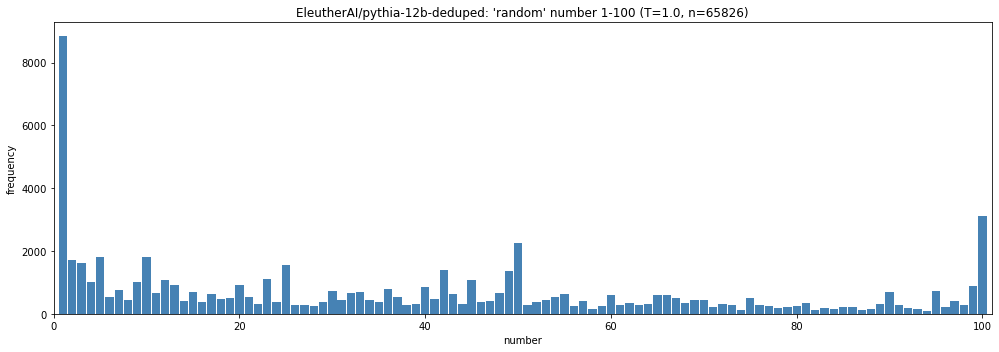

In [14]:
def parse_number(text):
    """First integer in 1..100 appearing in the generated text, else None."""
    for m in re.findall(r"\d+", text):
        v = int(m)
        if 1 <= v <= 100:
            return v
    return None

numbers = [parse_number(g) for g in generations]
valid = [v for v in numbers if v is not None]
print(f"parsed {len(valid)}/{len(numbers)} valid numbers in [1, 100]")

counts = pd.Series(valid).value_counts().sort_index()
print("most common:", counts.sort_values(ascending=False).head(10).to_dict())

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(np.arange(1, 101),
       [counts.get(i, 0) for i in range(1, 101)],
       width=0.9, color="steelblue")
ax.set_xlabel("number")
ax.set_ylabel("frequency")
ax.set_title(f"{MODEL_NAME}: 'random' number 1-100 (T={TEMPERATURE}, n={len(valid)})")
ax.set_xlim(0, 101)
plt.tight_layout()
plt.savefig("number_distribution.png", dpi=120)
plt.show()

In [15]:
# save the generations to disk
df = pd.DataFrame({"sample": range(len(generations)),
                   "raw": generations,
                   "number": numbers})

# CSV: one row per sample (raw text + parsed number)
df.to_csv("generations.csv", index=False)

# JSON: run metadata + every generation
record = {
    "model": MODEL_NAME,
    "prompt": PROMPT,
    "temperature": TEMPERATURE,
    "n_samples": len(generations),
    "n_valid": int(df["number"].notna().sum()),
    "generations": df.to_dict(orient="records"),
}
with open("generations.json", "w") as f:
    json.dump(record, f, indent=2)

print(f"saved {len(df)} generations to generations.csv and generations.json")
df.head()

saved 100000 generations to generations.csv and generations.json


,sample,raw,number
0,0,"0,75\n\nInput",75.0
1,1,10\nQuestion: Generate a,10.0
2,2,"16\nQuestion: Great,",16.0
3,3,`(Math.floor(,NaN
4,4,33\nTask: Describe,33.0


In [ ]:
# log-log analysis: is the "random" distribution a power law?
counts_full = pd.Series(valid).value_counts().reindex(range(1, 101), fill_value=0).sort_index()
n = np.arange(1, 101)
freq = counts_full.values.astype(float)
p = freq / len(valid)

# power-law fit  P(n) ~ n^-alpha  (least squares in log-log space, positive bins only)
mask = freq > 0
logn, logp = np.log10(n[mask]), np.log10(p[mask])
alpha, b = np.polyfit(logn, logp, 1)
fit = 10**b * n**alpha
r2 = 1 - np.sum((logp - (alpha*logn + b))**2) / np.sum((logp - logp.mean())**2)
print(f"power-law fit: P(n) ~ n^({alpha:.2f}), R^2 = {r2:.3f}")

# rank-frequency (Zipf)
rank_freq = np.sort(freq[freq > 0])[::-1]
ranks = np.arange(1, len(rank_freq) + 1)
sa, sb = np.polyfit(np.log10(ranks), np.log10(rank_freq), 1)
print(f"zipf fit: freq ~ rank^({sa:.2f})")

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
ax[0].scatter(n, p, s=28, color="steelblue", zorder=3, label="observed")
ax[0].plot(n, fit, "r--", lw=2, label=f"fit: $P(n)\\propto n^{{{alpha:.2f}}}$  ($R^2$={r2:.2f})")
ax[0].axhline(1/100, color="gray", ls=":", label="uniform (1/100)")
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("number  $n$"); ax[0].set_ylabel("probability  $P(n)$")
ax[0].set_title("Frequency vs. value (log-log)"); ax[0].legend(fontsize=9)

ax[1].scatter(ranks, rank_freq, s=28, color="darkorange", zorder=3, label="observed")
ax[1].plot(ranks, 10**sb * ranks**sa, "r--", lw=2, label=f"fit: freq $\\propto$ rank$^{{{sa:.2f}}}$")
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlabel("rank"); ax[1].set_ylabel("frequency")
ax[1].set_title("Rank-frequency (Zipf)"); ax[1].legend(fontsize=9)

fig.suptitle(f"{MODEL_NAME}: random 1-100 (T={TEMPERATURE}, n={len(valid)})", y=1.02)
plt.tight_layout()
plt.savefig("number_loglog.png", dpi=130, bbox_inches="tight")
plt.show()

In [ ]:
# Statsmodels OLS for the power-law fit above: log10(P) ~ log10(n)
# (uses the same n, p, mask defined in the cell above; slope = alpha exponent)
import statsmodels.api as sm

_X = sm.add_constant(np.log10(n[mask]))
_m = sm.OLS(np.log10(p[mask]), _X).fit()
print(_m.summary(xname=["const", "log10(n)"], yname="log10(P)"))
print(f"\nalpha (slope) : {_m.params[1]:.3f}")
print(f"R^2           : {_m.rsquared:.3f}")
print(f"slope p-value : {_m.pvalues[1]:.3e}")
print(f"F    p-value  : {_m.f_pvalue:.3e}")


In [11]:
# ---- few-shot prompting ----
# We randomize the in-context example numbers for every sample so the
# demonstrations do not anchor the model on any particular value
# (a fixed example set would bias the measured distribution).
N_SAMPLES_FS = 10000          # few-shot prompts are longer/slower; bump to match the zero-shot run if desired
K_SHOT = 5                    # number of demonstrations per prompt
BATCH_SIZE = 100
TEMPERATURE = 1
prompt_rng = np.random.default_rng(0)

def build_fewshot_prompt(k=K_SHOT):
    ex = prompt_rng.choice(np.arange(1, 101), size=k, replace=False)
    parts = [f"Question: Generate a random number between 1 and 100.\nAnswer: {e}" for e in ex]
    parts.append("Question: Generate a random number between 1 and 100.\nAnswer:")
    return "\n".join(parts)

fs_prompts = [build_fewshot_prompt() for _ in range(N_SAMPLES_FS)]
print("example few-shot prompt:\n")
print(fs_prompts[0])

example few-shot prompt:

Question: Generate a random number between 1 and 100.
Answer: 62
Question: Generate a random number between 1 and 100.
Answer: 51
Question: Generate a random number between 1 and 100.
Answer: 27
Question: Generate a random number between 1 and 100.
Answer: 31
Question: Generate a random number between 1 and 100.
Answer: 82
Question: Generate a random number between 1 and 100.
Answer:


In [12]:
# generate few-shot samples (prompts vary per sample, so we tokenize each batch with padding)
torch.manual_seed(0)
fs_generations = []
for start in range(0, N_SAMPLES_FS, BATCH_SIZE):
    batch_prompts = fs_prompts[start:start + BATCH_SIZE]
    enc = tokenizer(batch_prompts, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        out = model.generate(
            **enc,
            do_sample=True,
            temperature=TEMPERATURE,
            top_k=0,
            top_p=1.0,
            max_new_tokens=6,
            pad_token_id=tokenizer.pad_token_id,
        )
    new_tokens = out[:, enc["input_ids"].shape[1]:]
    fs_generations.extend(tokenizer.batch_decode(new_tokens, skip_special_tokens=True))
    print(f"generated {min(start + BATCH_SIZE, N_SAMPLES_FS)}/{N_SAMPLES_FS}")

print("\nsample raw outputs:")
for g in fs_generations[:10]:
    print(repr(g))

generated 100/10000
generated 200/10000
generated 300/10000
generated 400/10000
generated 500/10000
generated 600/10000
generated 700/10000
generated 800/10000
generated 900/10000
generated 1000/10000
generated 1100/10000
generated 1200/10000
generated 1300/10000
generated 1400/10000
generated 1500/10000
generated 1600/10000
generated 1700/10000
generated 1800/10000
generated 1900/10000
generated 2000/10000
generated 2100/10000
generated 2200/10000
generated 2300/10000
generated 2400/10000
generated 2500/10000
generated 2600/10000
generated 2700/10000
generated 2800/10000
generated 2900/10000
generated 3000/10000
generated 3100/10000
generated 3200/10000
generated 3300/10000
generated 3400/10000
generated 3500/10000
generated 3600/10000
generated 3700/10000
generated 3800/10000
generated 3900/10000
generated 4000/10000
generated 4100/10000
generated 4200/10000
generated 4300/10000
generated 4400/10000
generated 4500/10000
generated 4600/10000
generated 4700/10000
generated 4800/10000
g

few-shot valid: 9749/10000 (97.5%)
few-shot most common: {99: 162, 1: 161, 78: 145, 49: 141, 12: 139, 88: 134, 92: 134, 98: 133, 89: 132, 45: 131}
few-shot mean=50.45, median=50.0 (uniform mean=50.5)
saved generations_fewshot.csv


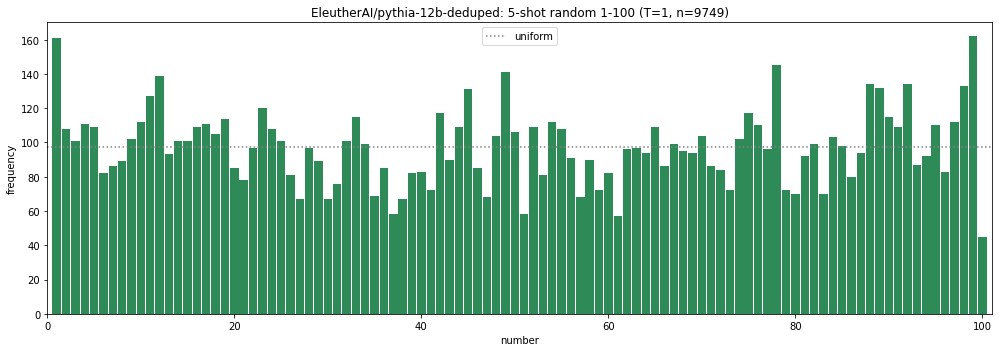

In [16]:
# parse, compare to zero-shot, and plot
fs_numbers = [parse_number(g) for g in fs_generations]
fs_valid = [v for v in fs_numbers if v is not None]
print(f"few-shot valid: {len(fs_valid)}/{len(fs_numbers)} ({100*len(fs_valid)/len(fs_numbers):.1f}%)")
# print(f"zero-shot valid was: {len(valid)}/{len(numbers)} ({100*len(valid)/len(numbers):.1f}%)")

fs_counts = pd.Series(fs_valid).value_counts().sort_index()
print("few-shot most common:", fs_counts.sort_values(ascending=False).head(10).to_dict())
print(f"few-shot mean={np.mean(fs_valid):.2f}, median={np.median(fs_valid):.1f} (uniform mean=50.5)")

# save few-shot generations
fs_df = pd.DataFrame({"sample": range(len(fs_generations)),
                      "prompt": fs_prompts[:len(fs_generations)],
                      "raw": fs_generations,
                      "number": fs_numbers})
fs_df.to_csv("generations_fewshot.csv", index=False)
print("saved generations_fewshot.csv")

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(np.arange(1, 101),
       [fs_counts.get(i, 0) for i in range(1, 101)],
       width=0.9, color="seagreen")
ax.axhline(len(fs_valid)/100, color="gray", ls=":", label="uniform")
ax.set_xlabel("number")
ax.set_ylabel("frequency")
ax.set_title(f"{MODEL_NAME}: {K_SHOT}-shot random 1-100 (T={TEMPERATURE}, n={len(fs_valid)})")
ax.set_xlim(0, 101)
ax.legend()
plt.tight_layout()
plt.savefig("number_distribution_fewshot.png", dpi=120)
plt.show()

In [7]:
# ---- ask for a list of random numbers in a single prompt ----
# Each generation yields a list; we parse up to NUMS_PER numbers from each.
N_PROMPTS = 5000              # number of independent generations
NUMS_PER = 25                 # numbers requested per prompt
PROMPT_MULTI = f"Question: Generate a list of random numbers between 1 and 100.\nAnswer:"
BATCH_SIZE = 100
TEMPERATURE = 1

multi_inputs = tokenizer([PROMPT_MULTI] * BATCH_SIZE, return_tensors="pt").to(device)

torch.manual_seed(0)
multi_generations = []
for start in range(0, N_PROMPTS, BATCH_SIZE):
    n = min(BATCH_SIZE, N_PROMPTS - start)
    batch = {k: v[:n] for k, v in multi_inputs.items()}
    with torch.no_grad():
        out = model.generate(
            **batch,
            do_sample=True,
            temperature=TEMPERATURE,
            top_k=0,
            top_p=1.0,
            max_new_tokens=128,   # enough room for ~25 numbers + separators
            pad_token_id=tokenizer.pad_token_id,
        )
    new_tokens = out[:, batch["input_ids"].shape[1]:]
    multi_generations.extend(tokenizer.batch_decode(new_tokens, skip_special_tokens=True))
    print(f"generated {start + n}/{N_PROMPTS}")

print("\nsample raw outputs:")
for g in multi_generations[:5]:
    print(repr(g))

generated 100/5000
generated 200/5000
generated 300/5000
generated 400/5000
generated 500/5000
generated 600/5000
generated 700/5000
generated 800/5000
generated 900/5000
generated 1000/5000
generated 1100/5000
generated 1200/5000
generated 1300/5000
generated 1400/5000
generated 1500/5000
generated 1600/5000
generated 1700/5000
generated 1800/5000
generated 1900/5000
generated 2000/5000
generated 2100/5000
generated 2200/5000
generated 2300/5000
generated 2400/5000
generated 2500/5000
generated 2600/5000
generated 2700/5000
generated 2800/5000
generated 2900/5000
generated 3000/5000
generated 3100/5000
generated 3200/5000
generated 3300/5000
generated 3400/5000
generated 3500/5000
generated 3600/5000
generated 3700/5000
generated 3800/5000
generated 3900/5000
generated 4000/5000
generated 4100/5000
generated 4200/5000
generated 4300/5000
generated 4400/5000
generated 4500/5000
generated 4600/5000
generated 4700/5000
generated 4800/5000
generated 4900/5000
generated 5000/5000

sample r

In [ ]:
# parse up to NUMS_PER numbers per generation, then pool and plot
def parse_number_list(text, cap=NUMS_PER):
    out = []
    for m in re.findall(r"\d+", text):
        v = int(m)
        if 1 <= v <= 100:
            out.append(v)
        if len(out) >= cap:
            break
    return out

multi_parsed = [parse_number_list(g) for g in multi_generations]
counts_per_gen = [len(x) for x in multi_parsed]
multi_valid = [v for sub in multi_parsed for v in sub]   # flatten

print(f"{len(multi_generations)} generations -> {len(multi_valid)} numbers in [1, 100]")
print(f"numbers parsed per generation: mean={np.mean(counts_per_gen):.1f}, "
      f"median={np.median(counts_per_gen):.0f}, max={max(counts_per_gen)} (requested {NUMS_PER})")
m = np.array(multi_valid)
print(f"mean={m.mean():.2f}, median={np.median(m):.1f} (uniform mean=50.5)")
mc = pd.Series(multi_valid).value_counts()
print("most common:", mc.head(10).to_dict())

# save
pd.DataFrame({"sample": range(len(multi_generations)),
              "raw": multi_generations,
              "numbers": ["|".join(map(str, x)) for x in multi_parsed],
              "n_parsed": counts_per_gen}).to_csv("generations_multi.csv", index=False)
print("saved generations_multi.csv")

NameError: name 'NUMS_PER' is not defined

NameError: name 'MODEL_NAME' is not defined

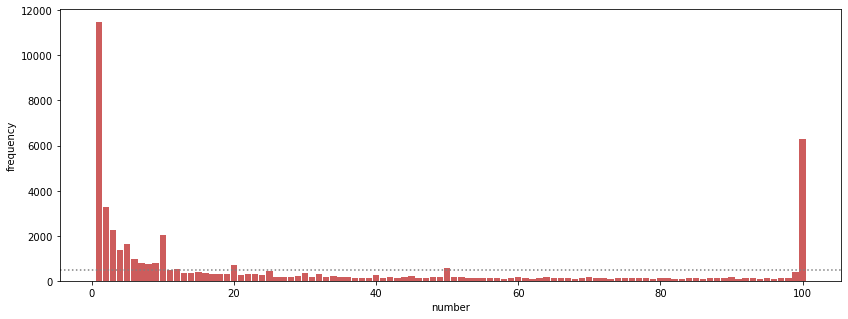

In [4]:
mc_full = pd.Series(multi_valid).value_counts().reindex(range(1, 101), fill_value=0).sort_index()
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(np.arange(1, 101), mc_full.values, width=0.9, color="indianred")
ax.axhline(len(multi_valid)/100, color="gray", ls=":", label="uniform")
ax.set_xlabel("number")
ax.set_ylabel("frequency")
ax.set_title(f"{MODEL_NAME}: random number generation")
ax.set_xlim(0, 101)
ax.legend()
plt.tight_layout()
plt.savefig("number_distribution_multi.png", dpi=120)
plt.show()

power-law fit: P(n) ~ n^(-0.83), R^2 = 0.659
zipf fit: freq ~ rank^(-1.01)


NameError: name 'MODEL_NAME' is not defined

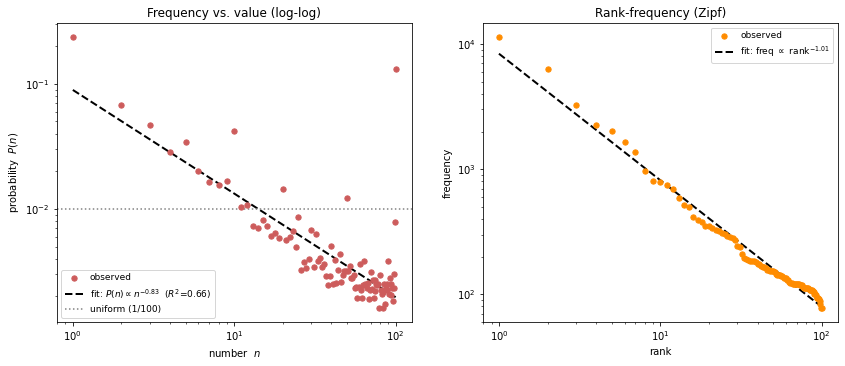

In [5]:
# log-log / power-law analysis for the "list of numbers" generation
mc_counts = pd.Series(multi_valid).value_counts().reindex(range(1, 101), fill_value=0).sort_index()
n = np.arange(1, 101)
freq = mc_counts.values.astype(float)
p = freq / len(multi_valid)

# power-law fit  P(n) ~ n^-alpha  (log-log least squares, positive bins only)
mask = freq > 0
logn, logp = np.log10(n[mask]), np.log10(p[mask])
alpha, b = np.polyfit(logn, logp, 1)
fit = 10**b * n**alpha
r2 = 1 - np.sum((logp - (alpha*logn + b))**2) / np.sum((logp - logp.mean())**2)
print(f"power-law fit: P(n) ~ n^({alpha:.2f}), R^2 = {r2:.3f}")

# rank-frequency (Zipf)
rank_freq = np.sort(freq[freq > 0])[::-1]
ranks = np.arange(1, len(rank_freq) + 1)
sa, sb = np.polyfit(np.log10(ranks), np.log10(rank_freq), 1)
print(f"zipf fit: freq ~ rank^({sa:.2f})")

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
ax[0].scatter(n, p, s=28, color="indianred", zorder=3, label="observed")
ax[0].plot(n, fit, "k--", lw=2, label=f"fit: $P(n)\\propto n^{{{alpha:.2f}}}$  ($R^2$={r2:.2f})")
ax[0].axhline(1/100, color="gray", ls=":", label="uniform (1/100)")
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("number  $n$"); ax[0].set_ylabel("probability  $P(n)$")
ax[0].set_title("Frequency vs. value (log-log)"); ax[0].legend(fontsize=9)

ax[1].scatter(ranks, rank_freq, s=28, color="darkorange", zorder=3, label="observed")
ax[1].plot(ranks, 10**sb * ranks**sa, "k--", lw=2, label=f"fit: freq $\\propto$ rank$^{{{sa:.2f}}}$")
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlabel("rank"); ax[1].set_ylabel("frequency")
ax[1].set_title("Rank-frequency (Zipf)"); ax[1].legend(fontsize=9)

fig.suptitle(f"{MODEL_NAME}: '{NUMS_PER} random numbers' prompt (T={TEMPERATURE}, n={len(multi_valid)})", y=1.02)
plt.tight_layout()
plt.savefig("number_loglog_multi.png", dpi=130, bbox_inches="tight")
plt.show()

In [6]:
# Statsmodels OLS for the power-law fit above: log10(P) ~ log10(n)
# (uses the same n, p, mask defined in the cell above; slope = alpha exponent)
import statsmodels.api as sm

_X = sm.add_constant(np.log10(n[mask]))
_m = sm.OLS(np.log10(p[mask]), _X).fit()
print(_m.summary(xname=["const", "log10(n)"], yname="log10(P)"))
print(f"\nalpha (slope) : {_m.params[1]:.3f}")
print(f"R^2           : {_m.rsquared:.3f}")
print(f"slope p-value : {_m.pvalues[1]:.3e}")
print(f"F    p-value  : {_m.f_pvalue:.3e}")


                            OLS Regression Results                            
Dep. Variable:               log10(P)   R-squared:                       0.659
Model:                            OLS   Adj. R-squared:                  0.656
Method:                 Least Squares   F-statistic:                     189.5
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           1.24e-24
Time:                        16:38:12   Log-Likelihood:                 1.2350
No. Observations:                 100   AIC:                             1.530
Df Residuals:                      98   BIC:                             6.740
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.0487      0.098    -10.688      0.0

In [7]:
# parse up to NUMS_PER numbers per generation, then pool and plot
def parse_number_list(text, cap=NUMS_PER):
    out = []
    for m in re.findall(r"\d+", text):
        v = int(m)
        if 1 <= v <= 100:
            out.append(v)
        if len(out) >= cap:
            break
    return out

multi_parsed = [parse_number_list(g) for g in multi_generations]
counts_per_gen = [len(x) for x in multi_parsed]
multi_valid = [v for sub in multi_parsed for v in sub]   # flatten

print(f"{len(multi_generations)} generations -> {len(multi_valid)} numbers in [1, 100]")
print(f"numbers parsed per generation: mean={np.mean(counts_per_gen):.1f}, "
      f"median={np.median(counts_per_gen):.0f}, max={max(counts_per_gen)}")
m = np.array(multi_valid)
print(f"mean={m.mean():.2f}, median={np.median(m):.1f} (uniform mean=50.5)")
print("most common:", mc.head(10).to_dict())

# save
pd.DataFrame({"sample": range(len(multi_generations)),
              "raw": multi_generations,
              "numbers": ["|".join(map(str, x)) for x in multi_parsed],
              "n_parsed": counts_per_gen}).to_csv("generations_multi.csv", index=False)
print("saved generations_multi.csv")

NameError: name 'NUMS_PER' is not defined

NameError: name 'MODEL_NAME' is not defined

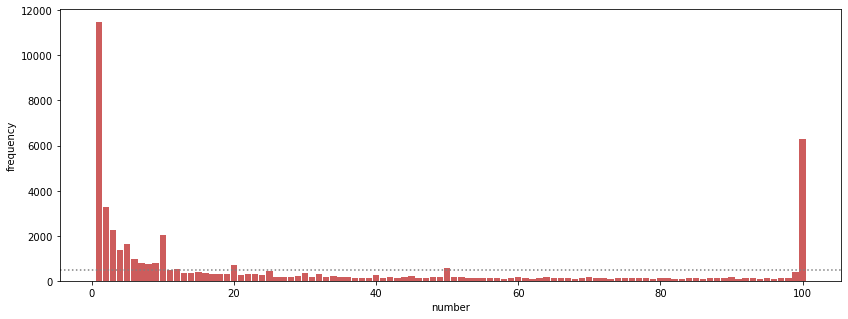

In [11]:
mc_full = pd.Series(multi_valid).value_counts().reindex(range(1, 101), fill_value=0).sort_index()
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(np.arange(1, 101), mc_full.values, width=0.9, color="indianred")
ax.axhline(len(multi_valid)/100, color="gray", ls=":", label="uniform")
ax.set_xlabel("number")
ax.set_ylabel("frequency")
ax.set_title(f"{MODEL_NAME}: random number generation")
ax.set_xlim(0, 101)
ax.legend()
plt.tight_layout()
plt.savefig("number_distribution_multi.png", dpi=120)
plt.show()

In [9]:
import pandas as pd

power-law fit: P(n) ~ n^(-0.83), R^2 = 0.659
zipf fit: freq ~ rank^(-1.01)


NameError: name 'MODEL_NAME' is not defined

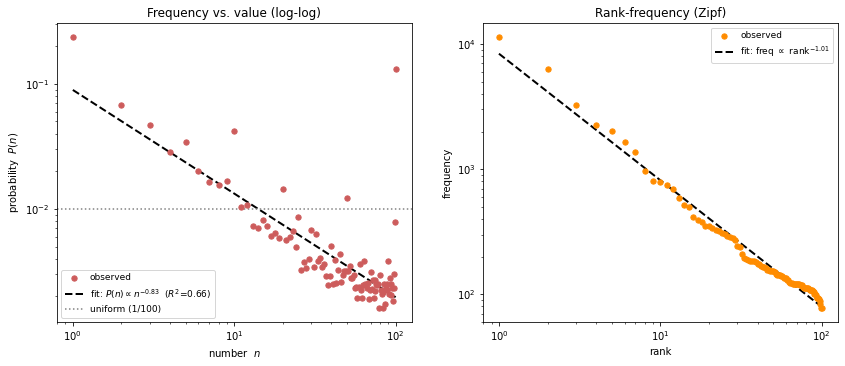

In [10]:
# log-log / power-law analysis for the "list of numbers" generation
mc_counts = pd.Series(multi_valid).value_counts().reindex(range(1, 101), fill_value=0).sort_index()
n = np.arange(1, 101)
freq = mc_counts.values.astype(float)
p = freq / len(multi_valid)

# power-law fit  P(n) ~ n^-alpha  (log-log least squares, positive bins only)
mask = freq > 0
logn, logp = np.log10(n[mask]), np.log10(p[mask])
alpha, b = np.polyfit(logn, logp, 1)
fit = 10**b * n**alpha
r2 = 1 - np.sum((logp - (alpha*logn + b))**2) / np.sum((logp - logp.mean())**2)
print(f"power-law fit: P(n) ~ n^({alpha:.2f}), R^2 = {r2:.3f}")

# rank-frequency (Zipf)
rank_freq = np.sort(freq[freq > 0])[::-1]
ranks = np.arange(1, len(rank_freq) + 1)
sa, sb = np.polyfit(np.log10(ranks), np.log10(rank_freq), 1)
print(f"zipf fit: freq ~ rank^({sa:.2f})")

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
ax[0].scatter(n, p, s=28, color="indianred", zorder=3, label="observed")
ax[0].plot(n, fit, "k--", lw=2, label=f"fit: $P(n)\\propto n^{{{alpha:.2f}}}$  ($R^2$={r2:.2f})")
ax[0].axhline(1/100, color="gray", ls=":", label="uniform (1/100)")
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("number  $n$"); ax[0].set_ylabel("probability  $P(n)$")
ax[0].set_title("Frequency vs. value (log-log)"); ax[0].legend(fontsize=9)

ax[1].scatter(ranks, rank_freq, s=28, color="darkorange", zorder=3, label="observed")
ax[1].plot(ranks, 10**sb * ranks**sa, "k--", lw=2, label=f"fit: freq $\\propto$ rank$^{{{sa:.2f}}}$")
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlabel("rank"); ax[1].set_ylabel("frequency")
ax[1].set_title("Rank-frequency (Zipf)"); ax[1].legend(fontsize=9)

fig.suptitle(f"{MODEL_NAME}: '{NUMS_PER} random numbers' prompt (T={TEMPERATURE}, n={len(multi_valid)})", y=1.02)
plt.tight_layout()
plt.savefig("number_loglog_multi.png", dpi=130, bbox_inches="tight")
plt.show()

In [15]:
# Statsmodels OLS for the power-law fit above: log10(P) ~ log10(n)
# (uses the same n, p, mask defined in the cell above; slope = alpha exponent)
import statsmodels.api as sm

_X = sm.add_constant(np.log10(n[mask]))
_m = sm.OLS(np.log10(p[mask]), _X).fit()
print(_m.summary(xname=["const", "log10(n)"], yname="log10(P)"))
print(f"\nalpha (slope) : {_m.params[1]:.3f}")
print(f"R^2           : {_m.rsquared:.3f}")
print(f"slope p-value : {_m.pvalues[1]:.3e}")
print(f"F    p-value  : {_m.f_pvalue:.3e}")


                            OLS Regression Results                            
Dep. Variable:               log10(P)   R-squared:                       0.659
Model:                            OLS   Adj. R-squared:                  0.656
Method:                 Least Squares   F-statistic:                     189.5
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           1.24e-24
Time:                        04:38:35   Log-Likelihood:                 1.2350
No. Observations:                 100   AIC:                             1.530
Df Residuals:                      98   BIC:                             6.740
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.0487      0.098    -10.688      0.0

multi_valid power-law fit:  slope=-0.8286  R^2=0.6591  p(slope)=1.241e-24  (n=100 points)
highlighted numbers: [10, 12, 15, 20, 24, 25, 30, 40, 50, 60, 70, 75, 80, 90, 100]


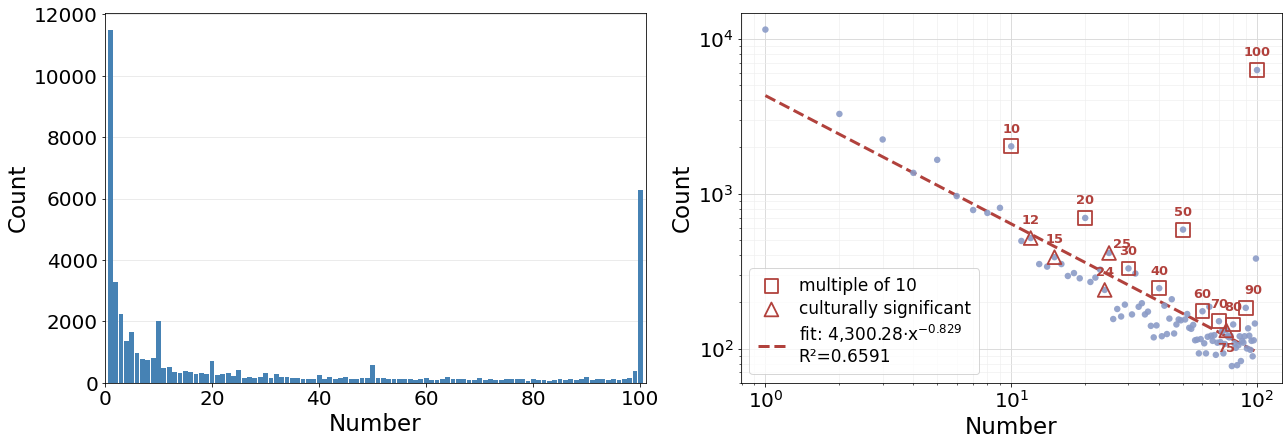

In [16]:
# ── "List of numbers" distribution (multi_valid), styled like metrics.ipynb Figure 1 ──
# Side-by-side: (left) linear count bar chart, (right) log-log power-law fit with
# prominent-number markers.  Requires `multi_valid` (run the Prerequisites cell first).
from scipy import stats

DOT = "#8b9bc7"      # blue-grey dots  (same palette as metrics Fig 1)
FIT = "#b1413c"      # brick-red fit line / prominent markers

vals   = np.arange(1, 101)
counts = (pd.Series(multi_valid).value_counts()
            .reindex(vals, fill_value=0).sort_index().values.astype(float))

mask = counts > 0
n = vals[mask]; c = counts[mask]
x = np.log10(n); y = np.log10(c)
lr = stats.linregress(x, y)                      # OLS log10(count) ~ log10(number)
slope, intercept = lr.slope, lr.intercept
resid = y - (slope * x + intercept)
sigma = resid.std()
r2 = lr.rvalue ** 2
C  = 10 ** intercept
print(f"multi_valid power-law fit:  slope={slope:.4f}  R^2={r2:.4f}  "
      f"p(slope)={lr.pvalue:.3e}  (n={len(n)} points)")

CULTURAL = {12, 15, 25, 24, 75}                  # all culturally significant numbers
exc = (n % 10 == 0) | np.isin(n, list(CULTURAL))  # ALL multiples of 10 + ALL cultural numbers
print("highlighted numbers:", list(n[exc]))

def exc_marker(v):
    if v in CULTURAL:  return "^"     # triangle: culturally significant
    if v % 10 == 0:    return "s"     # square: multiple of 10
    return "D"                         # diamond: other >1 sigma exception

EXC_CATEGORIES = [
    ("s", "multiple of 10"),
    ("^", "culturally significant"),
]

fig, (ax_bar, ax_fit) = plt.subplots(1, 2, figsize=(18, 6.3))

# ---- left panel: linear count bar chart ----
ax_bar.bar(vals, counts, width=0.9, color="steelblue")
ax_bar.set_xlabel("Number", fontsize=23)
ax_bar.set_ylabel("Count", fontsize=23)
ax_bar.set_xlim(0, 101)
ax_bar.grid(True, axis="y", color="#e6e6e6", linewidth=0.8)
ax_bar.set_axisbelow(True)
ax_bar.tick_params(labelsize=20)
ax_bar.yaxis.get_offset_text().set_fontsize(20)

# ---- right panel: log-log power-law fit ----
ax_fit.scatter(n, c, s=42, color=DOT, alpha=0.9, edgecolors="none", zorder=2)
en, ec = n[exc], c[exc]
emk = np.array([exc_marker(int(v)) for v in en])
for mk, lbl in EXC_CATEGORIES:
    sel = emk == mk
    if not sel.any():
        continue
    ax_fit.scatter(en[sel], ec[sel], s=190, facecolors="none", edgecolors=FIT,
                   marker=mk, linewidths=1.8, zorder=3, label=lbl)

for xi, yi in zip(en, ec):
    v = int(xi)
    if v == 90:
        xytext, ha, va = (8, 11), "center", "bottom"
    elif v == 75:                      # 75 label below its marker
        xytext, ha, va = (0, -11), "center", "top"
    elif v == 25:
        xytext, ha, va = (4, 2), "left", "bottom"
    elif v % 10 == 0 or v in CULTURAL:
        xytext, ha, va = (0, 11), "center", "bottom"
    else:
        xytext, ha, va = (10, 5), "left", "bottom"
    ax_fit.annotate(str(v), (xi, yi), textcoords="offset points",
                    xytext=xytext, ha=ha, va=va,
                    color=FIT, fontsize=13, fontweight="bold", zorder=4)

xs = np.array([1, 100])
ax_fit.plot(xs, C * xs**slope, "--", color=FIT, linewidth=3, zorder=1,
            label=f"fit: {C:,.2f}·x$^{{{slope:.3f}}}$\nR²={r2:.4f}")
ax_fit.set_xscale("log"); ax_fit.set_yscale("log")
ax_fit.set_xlabel("Number", fontsize=23)
ax_fit.set_ylabel("Count", fontsize=23)
ax_fit.grid(True, which="major", color="#d9d9d9", linewidth=0.9)
ax_fit.grid(True, which="minor", color="#eeeeee", linewidth=0.6)
ax_fit.set_axisbelow(True)
ax_fit.tick_params(labelsize=20)
leg = ax_fit.legend(loc="lower left", fontsize=17, frameon=True,
                    borderpad=0.5, handlelength=1.6, labelspacing=0.3)
leg.get_frame().set_edgecolor("#cccccc")

plt.tight_layout()
plt.savefig("number_multi_combined.png", dpi=130, bbox_inches="tight")
plt.show()


### "List of numbers" generation — distribution and power-law fit

Styled to match **Figure 1 in `metrics.ipynb`**. **(Left)** Frequency of each value
1–100 pooled across the "list of random numbers" generations (`multi_valid`).
**(Right)** The same counts on log-log axes with a least-squares power-law fit
(exponent shown as the slope, with R²). Brick-red markers flag prominent numbers:
**squares** = multiples of 10, **triangles** = culturally significant numbers,
**diamonds** = other values lying more than 1σ above the fit. Highlighting logic and
styling mirror the Pile figure so the model-generated distribution can be compared
to it directly.

multi_valid fit (excl. 1 & 100):  slope=-0.8335  R^2=0.8118  p(slope)=1.375e-36  (n=98 points)
highlighted numbers: [10, 12, 15, 20, 24, 25, 30, 40, 50, 60, 70, 75, 80, 90]


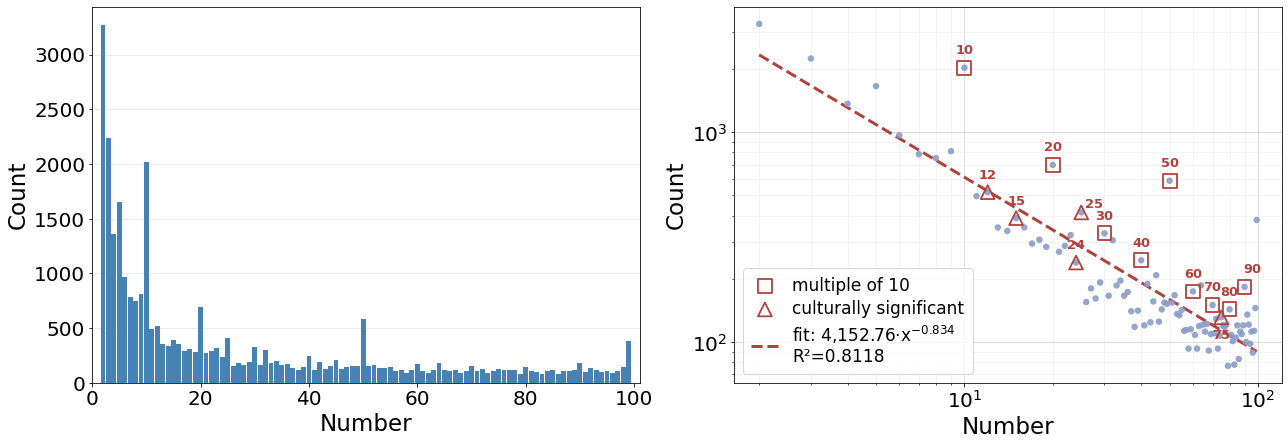

In [17]:
# ── multi_valid distribution EXCLUDING 1 and 100 (cleaner power-law fit) ──
# Same Figure-1 styling as the cell above, but values 1 and 100 are dropped from
# BOTH panels and the fit (endpoints that distort the log-log slope).
from scipy import stats

DOT = "#8b9bc7"; FIT = "#b1413c"

_all   = np.arange(1, 101)
_keep  = (_all != 1) & (_all != 100)
vals   = _all[_keep]                                       # 2..99
counts = (pd.Series(multi_valid).value_counts()
            .reindex(_all, fill_value=0).sort_index()
            .values.astype(float))[_keep]

mask = counts > 0
n = vals[mask]; c = counts[mask]
x = np.log10(n); y = np.log10(c)
lr = stats.linregress(x, y)
slope, intercept = lr.slope, lr.intercept
r2 = lr.rvalue ** 2
C  = 10 ** intercept
print(f"multi_valid fit (excl. 1 & 100):  slope={slope:.4f}  R^2={r2:.4f}  "
      f"p(slope)={lr.pvalue:.3e}  (n={len(n)} points)")

CULTURAL = {12, 15, 25, 24, 75}
exc = (n % 10 == 0) | np.isin(n, list(CULTURAL))   # ALL multiples of 10 + ALL cultural
print("highlighted numbers:", list(n[exc]))

def exc_marker(v):
    if v in CULTURAL:  return "^"
    if v % 10 == 0:    return "s"
    return "D"
EXC_CATEGORIES = [("s", "multiple of 10"), ("^", "culturally significant")]

fig, (ax_bar, ax_fit) = plt.subplots(1, 2, figsize=(18, 6.3))

# ---- left: bar chart ----
ax_bar.bar(vals, counts, width=0.9, color="steelblue")
ax_bar.set_xlabel("Number", fontsize=23)
ax_bar.set_ylabel("Count", fontsize=23)
ax_bar.set_xlim(0, 101)
ax_bar.grid(True, axis="y", color="#e6e6e6", linewidth=0.8)
ax_bar.set_axisbelow(True)
ax_bar.tick_params(labelsize=20)
ax_bar.yaxis.get_offset_text().set_fontsize(20)

# ---- right: log-log fit ----
ax_fit.scatter(n, c, s=42, color=DOT, alpha=0.9, edgecolors="none", zorder=2)
en, ec = n[exc], c[exc]
emk = np.array([exc_marker(int(v)) for v in en])
for mk, lbl in EXC_CATEGORIES:
    sel = emk == mk
    if not sel.any():
        continue
    ax_fit.scatter(en[sel], ec[sel], s=190, facecolors="none", edgecolors=FIT,
                   marker=mk, linewidths=1.8, zorder=3, label=lbl)
for xi, yi in zip(en, ec):
    v = int(xi)
    if v == 90:
        xytext, ha, va = (8, 11), "center", "bottom"
    elif v == 75:
        xytext, ha, va = (0, -11), "center", "top"
    elif v == 25:
        xytext, ha, va = (4, 2), "left", "bottom"
    elif v % 10 == 0 or v in CULTURAL:
        xytext, ha, va = (0, 11), "center", "bottom"
    else:
        xytext, ha, va = (10, 5), "left", "bottom"
    ax_fit.annotate(str(v), (xi, yi), textcoords="offset points",
                    xytext=xytext, ha=ha, va=va,
                    color=FIT, fontsize=13, fontweight="bold", zorder=4)
xs = np.array([n.min(), n.max()])
ax_fit.plot(xs, C * xs**slope, "--", color=FIT, linewidth=3, zorder=1,
            label=f"fit: {C:,.2f}·x$^{{{slope:.3f}}}$\nR²={r2:.4f}")
ax_fit.set_xscale("log"); ax_fit.set_yscale("log")
ax_fit.set_xlabel("Number", fontsize=23)
ax_fit.set_ylabel("Count", fontsize=23)
ax_fit.grid(True, which="major", color="#d9d9d9", linewidth=0.9)
ax_fit.grid(True, which="minor", color="#eeeeee", linewidth=0.6)
ax_fit.set_axisbelow(True)
ax_fit.tick_params(labelsize=20)
leg = ax_fit.legend(loc="lower left", fontsize=17, frameon=True,
                    borderpad=0.5, handlelength=1.6, labelspacing=0.3)
leg.get_frame().set_edgecolor("#cccccc")

plt.tight_layout()
plt.savefig("number_multi_combined_excl_1_100.png", dpi=130, bbox_inches="tight")
plt.show()


In [18]:
# Statsmodels OLS for the fit above: log10(P) ~ log10(n), multi_valid EXCLUDING 1 and 100
import statsmodels.api as sm

_all  = np.arange(1, 101)
_keep = (_all != 1) & (_all != 100)
_vals = _all[_keep]
_cnt  = (pd.Series(multi_valid).value_counts()
           .reindex(_all, fill_value=0).sort_index().values.astype(float))[_keep]
_p    = _cnt / len(multi_valid)
_pos  = _cnt > 0

_X = sm.add_constant(np.log10(_vals[_pos]))
_m = sm.OLS(np.log10(_p[_pos]), _X).fit()
print(_m.summary(xname=["const", "log10(n)"], yname="log10(P)"))
print(f"\nalpha (slope) : {_m.params[1]:.3f}")
print(f"R^2           : {_m.rsquared:.3f}")
print(f"slope p-value : {_m.pvalues[1]:.3e}")
print(f"F    p-value  : {_m.f_pvalue:.3e}")


                            OLS Regression Results                            
Dep. Variable:               log10(P)   R-squared:                       0.812
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     414.0
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           1.37e-36
Time:                        17:03:14   Log-Likelihood:                 47.915
No. Observations:                  98   AIC:                            -91.83
Df Residuals:                      96   BIC:                            -86.66
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.0639      0.067    -15.895      0.0

### multi_valid power-law fit — excluding endpoints 1 and 100

Identical to the figure above, but the values **1 and 100 are dropped** from both the
plot and the fit. These endpoints sit off the power-law trend (1 is anomalously
frequent; 100 is the boundary of the requested range), so removing them gives a much
cleaner fit: **R² rises from ~0.66 to ~0.81** while the exponent is essentially
unchanged (α ≈ −0.83). The statsmodels cell reports the full regression on the same
98-point subset.